# Misconception-Channel Modelling and Comparison

Loads the saved misconception labels (from notebook 03), joins them to the
correctness/KC data, and compares:

- **Baseline**: correctness-only BKT.
- **Design 1 (pooled)**: + misconception emission, pooled across families.
- **Design 2a (family)**: + family-conditioned misconception emission.

each at **binary** and **trinary** granularity. Reports AUC / Acc / log-lik /
Brier overall, against the majority-class floor, in one table.

No API calls here; this is pure modelling on the saved labels.


## Setup

In [1]:
import os
from pathlib import Path
_here = Path.cwd()
for _c in [_here, *_here.parents]:
    if (_c / "data" / "annotated").exists():
        os.chdir(_c); break
import sys
sys.path.insert(0, str(Path.cwd() / "extension"))
print("cwd:", os.getcwd())


cwd: /Users/tandon.utsav2/Desktop/Experiment_1


In [2]:
from ast import literal_eval
import pandas as pd, numpy as np, time
from myext import (filtering, bkt, bkt_design1, bkt_design2, bkt_design3, bkt_design4, bkt_design5, bkt_design6, bkt_design7,
                   bkt_mc_common, labels_io, diagnostics, param_audit)

CONV = {c: literal_eval for c in ["annotation", "dialogue"]}
def load(split):
    df = pd.read_csv(f"data/annotated/mathdial_{split}_atc.csv", converters=CONV)
    df, _ = filtering.drop_failed_annotations(df); df.index = df["index"]
    return df
def turn_table(df):
    rows=[]
    for didx, ann in zip(df.index, df["annotation"]):
        if not isinstance(ann, dict): continue
        for tk, info in ann.items():
            if not isinstance(info, dict) or "correct" not in info or "kcs" not in info: continue
            c = 1 if info["correct"] in (True,1,"true","correct") else 0
            for kc in info["kcs"]: rows.append((didx, tk, c, kc))
    return pd.DataFrame(rows, columns=["dialogue_idx","turn","correct","kc"])

train = load("train"); test = load("test")
train_long = turn_table(train); test_long = turn_table(test)

# degenerate-KC filter (same as the baseline notebook)
train_f, test_f, fres = filtering.filter_splits(train_long, test_long,
                                                drop_no_variation=True, min_count=1)
print(fres.summary())

# majority-class floor
per_turn = test_long.groupby(["dialogue_idx","turn"])["correct"].first()
floor = max(per_turn.mean(), 1 - per_turn.mean())
print(f"majority-class floor (test Acc): {floor:.3f}")


KCs: 143 -> 124 (dropped 19)
observations: 29478 -> 29447 (removed 31, 0.11%)
drop reasons: no_variation=19
majority-class floor (test Acc): 0.588


## Load and join the saved misconception labels

From `data/misconception/` (written by notebook 03). The per-turn label
broadcasts across the KCs each turn invokes.


In [3]:
train_lab = labels_io.load_labels("train")
test_lab = labels_io.load_labels("test")
print("train labels:", len(train_lab), "| test labels:", len(test_lab))
print("train misc dist:", train_lab["misc"].value_counts(normalize=True).round(3).to_dict())

train_mc = labels_io.join_misc(train_f, train_lab)
test_mc  = labels_io.join_misc(test_long, test_lab)
print("joined train rows:", len(train_mc), "| any unlabelled misc:",
      (train_mc["misc"] == "not_evidenced").mean().round(3), "not_evidenced frac")


train labels: 13219 | test labels: 3498
train misc dist: {'present': 0.526, 'absent': 0.322, 'not_evidenced': 0.152}
joined train rows: 29447 | any unlabelled misc: 0.13 not_evidenced frac


## Fit all models

Baseline plus the four augmented variants (2 designs x 2 granularities).
Each fit is pure-Python EM; the family design is the slowest. Cached nowhere,
so this runs the fits fresh each time (a few minutes total).


In [4]:
N_RESTARTS = 3
results = {}

t0 = time.time()
fb = bkt.fit_bkt(train_f, n_restarts=N_RESTARTS, verbose=False)
ov, fn, _ = bkt.evaluate(fb, test_long)
results["baseline (correctness only)"] = ov
print(f"baseline done ({time.time()-t0:.0f}s)")

fit_fns = {"D1 pooled": bkt_design1.fit_design1,
           "D2a family": bkt_design2.fit_design2,
           "D3 joint": bkt_design3.fit_design3,
           "D4 transition": bkt_design4.fit_design4}
for label, fit_fn in fit_fns.items():
    for gran in ["binary", "trinary"]:
        t0 = time.time()
        fm = fit_fn(train_mc, gran, n_restarts=N_RESTARTS, verbose=False)
        ovm, fnm, _ = bkt_mc_common.evaluate_mc(fm, test_mc)
        name = f"{label} + {gran}"
        results[name] = ovm
        print(f"{name} done ({time.time()-t0:.0f}s)")


baseline done (67s)
D1 pooled + binary done (46s)
D1 pooled + trinary done (35s)
D2a family + binary done (44s)
D2a family + trinary done (44s)
D3 joint + binary done (62s)
D3 joint + trinary done (68s)
D4 transition + binary done (82s)
D4 transition + trinary done (83s)


## Design 5: tempered-emission split sweep

A weighted variant of Design 1. For a split (a, b) with a + b = 100, the
correctness emission is raised to the power 2a/100 and the misconception
emission to 2b/100, so the weight tunes how much each channel moves the BKT
belief. The endpoints and midpoint are anchored: 100-0 is the correctness-only
baseline, 50-50 is exactly Design 1, and 0-100 is misconception-only. The sweep
below fits every split at both granularities on the same `train_mc` / `test_mc`
frames the other designs use, and adds the results to the shared `results` dict
so they appear in the comparison table above when it is re-run.

In [5]:
# Tempered-emission sweep. Reuses train_mc / test_mc and the shared results dict.
from sklearn.metrics import roc_auc_score

SPLITS = bkt_design5.DEFAULT_SPLITS   # [(100,0),(80,20),(60,40),(50,50),(40,60),(20,80),(0,100)]
sweep_rows = []
for gran in ["binary", "trinary"]:
    for sp in SPLITS:
        t0 = time.time()
        fm = bkt_design5.fit_design5(train_mc, gran, split=sp,
                                     n_restarts=N_RESTARTS, verbose=False)
        ovm, _fnm, _pred = bkt_mc_common.evaluate_mc(fm, test_mc)
        name = f"D5 split {sp[0]}-{sp[1]} + {gran}"
        results[name] = ovm           # flows into the comparison table
        sweep_rows.append({"granularity": gran, "split": f"{sp[0]}-{sp[1]}",
                           "corr_weight": sp[0], "misc_weight": sp[1],
                           "AUC": round(ovm.auc, 4), "Acc": round(ovm.accuracy, 4),
                           "Brier": round(ovm.brier, 4)})
        print(f"{name} done ({time.time()-t0:.0f}s)  AUC={ovm.auc:.4f}")

sweep = pd.DataFrame(sweep_rows)
# baseline (100-0) per granularity for the delta column
base_by_gran = {g: sweep[(sweep.granularity==g) & (sweep.split=="100-0")]["AUC"].iloc[0]
                for g in sweep.granularity.unique()}
sweep["dAUC_vs_base"] = sweep.apply(
    lambda r: round(r["AUC"] - base_by_gran[r["granularity"]], 4), axis=1)


D5 split 100-0 + binary done (53s)  AUC=0.6214
D5 split 80-20 + binary done (57s)  AUC=0.6235
D5 split 60-40 + binary done (49s)  AUC=0.6169
D5 split 50-50 + binary done (59s)  AUC=0.6040
D5 split 40-60 + binary done (48s)  AUC=0.5978
D5 split 20-80 + binary done (37s)  AUC=0.5922
D5 split 0-100 + binary done (38s)  AUC=0.5889
D5 split 100-0 + trinary done (50s)  AUC=0.6214
D5 split 80-20 + trinary done (47s)  AUC=0.6256
D5 split 60-40 + trinary done (49s)  AUC=0.6275
D5 split 50-50 + trinary done (46s)  AUC=0.6193
D5 split 40-60 + trinary done (42s)  AUC=0.6104
D5 split 20-80 + trinary done (31s)  AUC=0.6020
D5 split 0-100 + trinary done (34s)  AUC=0.5982


In [6]:
# Sweep table, ordered by misconception weight within each granularity
for g in sweep["granularity"].unique():
    print(f"=== {g} ===")
    print(sweep[sweep.granularity==g]
          .sort_values("misc_weight")[["split","AUC","Acc","Brier","dAUC_vs_base"]]
          .to_string(index=False))
    print()

# Does any split beat the correctness-only baseline by more than noise?
better = sweep[sweep["dAUC_vs_base"] > 0]
if len(better):
    print("Splits above their baseline:")
    print(better[["granularity","split","dAUC_vs_base"]].to_string(index=False))
else:
    print("No split beats the correctness-only baseline "
          "(monotone redundancy pattern, as expected).")


=== binary ===
split    AUC    Acc  Brier  dAUC_vs_base
100-0 0.6214 0.6099 0.2507        0.0000
80-20 0.6235 0.6084 0.2453        0.0021
60-40 0.6169 0.5975 0.2413       -0.0045
50-50 0.6040 0.5792 0.2466       -0.0174
40-60 0.5978 0.5633 0.2533       -0.0236
20-80 0.5922 0.5616 0.2633       -0.0292
0-100 0.5889 0.5592 0.2686       -0.0325

=== trinary ===
split    AUC    Acc  Brier  dAUC_vs_base
100-0 0.6214 0.6099 0.2507        0.0000
80-20 0.6256 0.6108 0.2443        0.0042
60-40 0.6275 0.6097 0.2373        0.0061
50-50 0.6193 0.6002 0.2386       -0.0021
40-60 0.6104 0.5888 0.2433       -0.0110
20-80 0.6020 0.5782 0.2533       -0.0194
0-100 0.5982 0.5714 0.2568       -0.0232

Splits above their baseline:
granularity split  dAUC_vs_base
     binary 80-20        0.0021
    trinary 80-20        0.0042
    trinary 60-40        0.0061


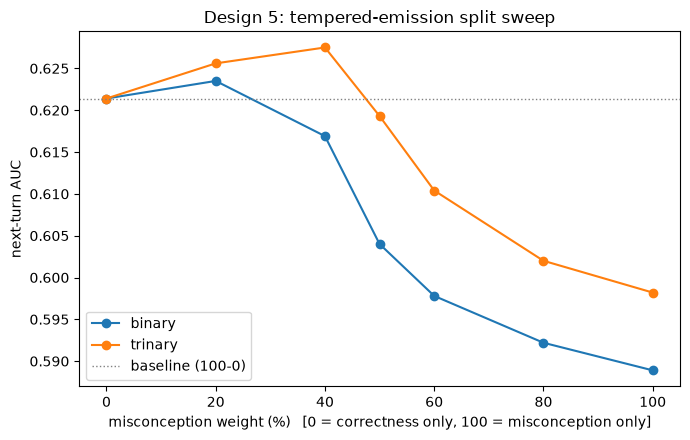

saved design5_sweep.png


In [7]:
# AUC vs misconception weight, one line per granularity
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 4.5))
for g in sweep["granularity"].unique():
    sub = sweep[sweep.granularity==g].sort_values("misc_weight")
    ax.plot(sub["misc_weight"], sub["AUC"], marker="o", label=g)
ax.axhline(base_by_gran[list(base_by_gran)[0]], ls=":", c="grey", lw=1,
           label="baseline (100-0)")
ax.set_xlabel("misconception weight (%)   [0 = correctness only, 100 = misconception only]")
ax.set_ylabel("next-turn AUC")
ax.set_title("Design 5: tempered-emission split sweep")
ax.legend(); fig.tight_layout()
fig.savefig("design5_sweep.png", dpi=140)
plt.show()
print("saved design5_sweep.png")


## Design 6: tempered FAMILY-CONDITIONED emission

The same correctness-vs-misconception tempering as Design 5, but on Design 2a's
family-specific misconception emission. Same weight axis (100-0 is correctness
only, 50-50 is exactly Design 2a, 0-100 is family-specific misconception only).
This tests whether the tempering curve looks different once the emission is
family-specific. Results are added to the shared `results` dict.

In [8]:
# Design 6 sweep: tempered family-conditioned emission. Same axis as D5.
d6_rows = []
for gran in ["binary", "trinary"]:
    for sp in bkt_design6.DEFAULT_SPLITS:
        t0 = time.time()
        fm = bkt_design6.fit_design6(train_mc, gran, split=sp,
                                     n_restarts=N_RESTARTS, verbose=False)
        ovm, _f, _p = bkt_mc_common.evaluate_mc(fm, test_mc)
        results[f"D6 split {sp[0]}-{sp[1]} + {gran}"] = ovm
        d6_rows.append({"granularity": gran, "split": f"{sp[0]}-{sp[1]}",
                        "misc_weight": sp[1], "AUC": round(ovm.auc, 4),
                        "Brier": round(ovm.brier, 4)})
        print(f"D6 {sp[0]}-{sp[1]} + {gran}: AUC={ovm.auc:.4f} ({time.time()-t0:.0f}s)")

d6 = pd.DataFrame(d6_rows)
d6_base = {g: d6[(d6.granularity==g)&(d6.split=="100-0")]["AUC"].iloc[0]
           for g in d6.granularity.unique()}
d6["dAUC_vs_base"] = d6.apply(lambda r: round(r["AUC"]-d6_base[r["granularity"]],4), axis=1)
for g in d6.granularity.unique():
    print(f"\n=== D6 {g} ===")
    print(d6[d6.granularity==g].sort_values("misc_weight")
          [["split","AUC","Brier","dAUC_vs_base"]].to_string(index=False))


D6 100-0 + binary: AUC=0.6223 (53s)
D6 80-20 + binary: AUC=0.6224 (55s)
D6 60-40 + binary: AUC=0.6170 (50s)
D6 50-50 + binary: AUC=0.6060 (56s)
D6 40-60 + binary: AUC=0.6008 (49s)
D6 20-80 + binary: AUC=0.5933 (42s)
D6 0-100 + binary: AUC=0.5905 (37s)
D6 100-0 + trinary: AUC=0.6223 (52s)
D6 80-20 + trinary: AUC=0.6245 (46s)
D6 60-40 + trinary: AUC=0.6260 (55s)
D6 50-50 + trinary: AUC=0.6201 (56s)
D6 40-60 + trinary: AUC=0.6096 (54s)
D6 20-80 + trinary: AUC=0.6022 (33s)
D6 0-100 + trinary: AUC=0.5972 (28s)

=== D6 binary ===
split    AUC  Brier  dAUC_vs_base
100-0 0.6223 0.2506        0.0000
80-20 0.6224 0.2453        0.0001
60-40 0.6170 0.2426       -0.0053
50-50 0.6060 0.2469       -0.0163
40-60 0.6008 0.2522       -0.0215
20-80 0.5933 0.2607       -0.0290
0-100 0.5905 0.2630       -0.0318

=== D6 trinary ===
split    AUC  Brier  dAUC_vs_base
100-0 0.6223 0.2506        0.0000
80-20 0.6245 0.2445        0.0022
60-40 0.6260 0.2380        0.0037
50-50 0.6201 0.2387       -0.0022
40-60 0.

## Design 7: partial-pooling sweep (different axis)

This sweep does **not** vary the correctness-vs-misconception balance. It holds
the misconception channel at full strength (ordinary Design 2a product) and
varies only how far each family's misconception emission is shrunk toward the
pooled estimate, by a weight lambda. lambda=0 is the pooled emission (Design 1's
emission on a shared core), lambda=1 is Design 2a exactly. The core BKT
parameters are held fixed across the sweep, so lambda isolates the
family-specificity of the emission. An interior peak would indicate the
per-family signal is real but noisy and that shrinkage helps.

In [9]:
# Design 7 sweep: partial pooling. Fit once, sweep lambda at predict time.
d7_frames = {}
for gran in ["binary", "trinary"]:
    t0 = time.time()
    fitted7 = bkt_design7.fit_design7(train_mc, gran, n_restarts=N_RESTARTS, verbose=False)
    sw = fitted7.evaluate_sweep(test_mc, lambdas=bkt_design7.DEFAULT_LAMBDAS)
    sw["granularity"] = gran
    d7_frames[gran] = sw
    # add endpoints + a couple of interior lambdas to the shared results table
    for _, r in sw.iterrows():
        # represent each lambda as a pseudo-model row only at endpoints + 0.5 to avoid clutter
        if r["lambda"] in (0.0, 0.5, 1.0):
            class _M:  # lightweight holder matching the .auc/.accuracy/.brier interface used by the table
                pass
            m=_M(); m.auc=r["AUC"]; m.accuracy=r["Acc"]; m.brier=r["Brier"]; m.log_likelihood=float("nan")
            results[f"D7 lambda={r['lambda']:.1f} + {gran}"] = m
    print(f"D7 {gran} done ({time.time()-t0:.0f}s)")
    print(sw[["lambda","AUC","Acc","Brier","dAUC_vs_pooled"]].to_string(index=False))
    print()

d7 = pd.concat(d7_frames.values(), ignore_index=True)
# interior-peak check
for gran in d7["granularity"].unique():
    sub = d7[d7.granularity==gran]
    best = sub.loc[sub["AUC"].idxmax()]
    interior = best["lambda"] not in (0.0, 1.0)
    print(f"{gran}: best lambda={best['lambda']:.1f} (AUC={best['AUC']:.4f})"
          f"{'  <-- INTERIOR PEAK (partial pooling helps)' if interior else ''}")


D7 binary done (46s)
 lambda    AUC    Acc  Brier  dAUC_vs_pooled
    0.0 0.6067 0.5819 0.2461          0.0000
    0.2 0.6073 0.5843 0.2460          0.0006
    0.4 0.6075 0.5843 0.2460          0.0008
    0.5 0.6074 0.5837 0.2460          0.0007
    0.6 0.6074 0.5837 0.2461          0.0007
    0.8 0.6069 0.5837 0.2463          0.0002
    1.0 0.6060 0.5829 0.2469         -0.0007

D7 trinary done (45s)
 lambda    AUC    Acc  Brier  dAUC_vs_pooled
    0.0 0.6230 0.6013 0.2376          0.0000
    0.2 0.6228 0.6009 0.2377         -0.0002
    0.4 0.6226 0.6014 0.2378         -0.0004
    0.5 0.6224 0.5994 0.2379         -0.0006
    0.6 0.6223 0.5995 0.2380         -0.0007
    0.8 0.6218 0.5994 0.2382         -0.0012
    1.0 0.6201 0.5984 0.2387         -0.0029

binary: best lambda=0.4 (AUC=0.6075)  <-- INTERIOR PEAK (partial pooling helps)
trinary: best lambda=0.0 (AUC=0.6230)


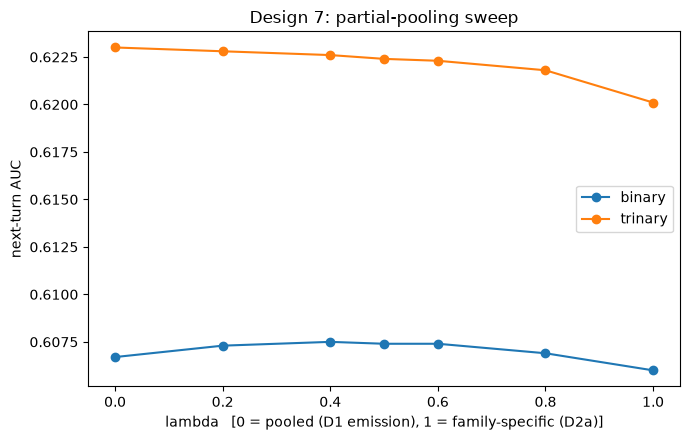

saved design7_sweep.png


In [10]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 4.5))
for gran in d7["granularity"].unique():
    sub = d7[d7.granularity==gran].sort_values("lambda")
    ax.plot(sub["lambda"], sub["AUC"], marker="o", label=gran)
ax.set_xlabel("lambda   [0 = pooled (D1 emission), 1 = family-specific (D2a)]")
ax.set_ylabel("next-turn AUC")
ax.set_title("Design 7: partial-pooling sweep")
ax.legend(); fig.tight_layout()
fig.savefig("design7_sweep.png", dpi=140); plt.show()
print("saved design7_sweep.png")


## Comparison table

In [11]:
rows = []
for name, m in results.items():
    rows.append({"model": name, "Acc": round(m.accuracy,4), "AUC": round(m.auc,4),
                 "LogLik": round(m.log_likelihood,4), "Brier": round(m.brier,4)})
tbl = pd.DataFrame(rows)
tbl["floor_Acc"] = round(floor,3)
# delta AUC vs baseline
base_auc = results["baseline (correctness only)"].auc
tbl["dAUC_vs_base"] = (tbl["AUC"] - base_auc).round(4)
print(tbl.to_string(index=False))


                      model    Acc    AUC  LogLik  Brier  floor_Acc  dAUC_vs_base
baseline (correctness only) 0.6135 0.6271 -0.6503 0.2291      0.588        0.0000
         D1 pooled + binary 0.5792 0.6040 -0.6959 0.2466      0.588       -0.0231
        D1 pooled + trinary 0.6002 0.6193 -0.6749 0.2386      0.588       -0.0078
        D2a family + binary 0.5829 0.6060 -0.6980 0.2469      0.588       -0.0211
       D2a family + trinary 0.5984 0.6201 -0.6773 0.2387      0.588       -0.0070
          D3 joint + binary 0.5721 0.5952 -0.6780 0.2391      0.588       -0.0319
         D3 joint + trinary 0.6070 0.6180 -0.6602 0.2312      0.588       -0.0091
     D4 transition + binary 0.6116 0.6267 -0.6540 0.2300      0.588       -0.0004
    D4 transition + trinary 0.6081 0.6231 -0.6669 0.2321      0.588       -0.0040
    D5 split 100-0 + binary 0.6099 0.6214 -0.7350 0.2507      0.588       -0.0057
    D5 split 80-20 + binary 0.6084 0.6235 -0.7062 0.2453      0.588       -0.0036
    D5 split 60-

### Reading the table

- **dAUC_vs_base** is the headline: does adding the misconception channel raise
  AUC over correctness-only BKT, and by how much?
- Compare **binary vs trinary** within each design: does modelling the
  not-evidenced turns as no-update (trinary) beat folding them into absent
  (binary)?
- Compare **D1 pooled vs D2a family**: does family-conditioning the
  misconception emission help, or is the data too sparse for it (in which case
  pooled wins)?
- All should clear the majority-class floor on AUC. Small deltas are expected;
  the channel is a refinement on top of correctness, not a replacement.

These are proof-of-concept results on simulated-student labels; interpret the
direction and sign of the effect rather than absolute magnitudes.


## Optional: paired significance

If you want a paired test on whether the channel's per-turn predictions differ
from baseline, run McNemar or a bootstrap over per-turn correctness predictions.
Stub below compares the best augmented model's predictions to baseline.


In [12]:
# bootstrap CI on the AUC difference (best augmented vs baseline)
from sklearn.metrics import roc_auc_score
best_name = max((n for n in results if n!="baseline (correctness only)"),
                key=lambda n: results[n].auc)
print("best augmented model:", best_name)

base_pred = fb.predict_long(test_long)[["dialogue_idx","turn","kc","correct"]].copy()
base_pred["pred_base"] = bkt.FittedBKT(fb.per_skill, fb.fallback).predict_long(test_long)["pred"].values
# refit best for its predictions
g = "binary" if "binary" in best_name else "trinary"
fit_fn = (bkt_design1.fit_design1 if "pooled" in best_name
          else bkt_design3.fit_design3 if "joint" in best_name
          else bkt_design2.fit_design2)
fm_best = fit_fn(train_mc, g, n_restarts=N_RESTARTS, verbose=False)
mc_pred = bkt_mc_common.evaluate_mc(fm_best, test_mc)[2]

y = base_pred["correct"].to_numpy()
pb = base_pred["pred_base"].to_numpy()
pm = mc_pred.sort_values(["dialogue_idx","kc","turn"])["pred"].to_numpy()[:len(y)]

rng = np.random.default_rng(0); diffs=[]
for _ in range(1000):
    idx = rng.integers(0, len(y), len(y))
    try:
        diffs.append(roc_auc_score(y[idx], pm[idx]) - roc_auc_score(y[idx], pb[idx]))
    except ValueError:
        pass
diffs = np.array(diffs)
print(f"AUC difference (best - baseline): {diffs.mean():.4f} "
      f"[{np.percentile(diffs,2.5):.4f}, {np.percentile(diffs,97.5):.4f}] (95% bootstrap CI)")
print("CI excludes 0:", not (np.percentile(diffs,2.5) < 0 < np.percentile(diffs,97.5)))


best augmented model: D5 split 60-40 + trinary
AUC difference (best - baseline): -0.0793 [-0.0958, -0.0617] (95% bootstrap CI)
CI excludes 0: True


## Diagnostics: why does the channel behave as it does?

Given that the labels are highly informative (large `P(correct|misc)` gap) yet
the channel does not help, these two analyses explain why.

**Overconfidence**: if the misconception is nearly a copy of correctness, the
emission double-counts it and the belief becomes overconfident. Expect the
augmented model to be more extreme and worse calibrated (higher ECE, Brier).

**Off-diagonal**: the channel can only add information correctness lacks on
turns where misconception and correctness DISAGREE (present-but-correct,
absent-but-incorrect). This splits performance by agree/disagree to locate
where the channel helps or hurts.


In [13]:
from myext import diagnostics

base_pred = fb.predict_long(test_long)
bp = base_pred.sort_values(['dialogue_idx','kc','turn']).reset_index(drop=True)

# diagnose EVERY augmented design (refit each, trinary, for its predictions)
design_fits = {
    'D1 pooled':     (bkt_design1.fit_design1, 'trinary'),
    'D2a family':    (bkt_design2.fit_design2, 'trinary'),
    'D3 joint':      (bkt_design3.fit_design3, 'trinary'),
    'D4 transition': (bkt_design4.fit_design4, 'trinary'),
}
for name, (fit_fn, gran) in design_fits.items():
    fm = fit_fn(train_mc, gran, n_restarts=N_RESTARTS, verbose=False)
    aug_pred = fm.predict_long(test_mc)
    ap = aug_pred.sort_values(['dialogue_idx','kc','turn']).reset_index(drop=True)
    print(f'\n########## {name} (trinary) ##########')
    oc = diagnostics.overconfidence_report(bp, ap)
    print('  overconfidence: aug_extremity=%.3f (base %.3f), aug_ece=%.3f (base %.3f), aug_brier=%.3f (base %.3f)'
          % (oc['aug_extremity'], oc['base_extremity'], oc['aug_ece'], oc['base_ece'], oc['aug_brier'], oc['base_brier']))
    od = diagnostics.offdiagonal_report(aug_pred, base_pred, test_mc)
    print(od.to_string(index=False))



########## D1 pooled (trinary) ##########
  overconfidence: aug_extremity=0.150 (base 0.108), aug_ece=0.063 (base 0.027), aug_brier=0.239 (base 0.229)
       subset    n  frac_correct  base_AUC  aug_AUC  base_acc  aug_acc    dAUC
        agree 2828         0.274    0.6482   0.6728    0.6970   0.7090  0.0246
     disagree 2161         0.536    0.5730   0.5265    0.5160   0.4845 -0.0465
not_evidenced 2457         0.457    0.6330   0.6100    0.6032   0.5767 -0.0230

########## D2a family (trinary) ##########
  overconfidence: aug_extremity=0.152 (base 0.108), aug_ece=0.063 (base 0.027), aug_brier=0.239 (base 0.229)
       subset    n  frac_correct  base_AUC  aug_AUC  base_acc  aug_acc    dAUC
        agree 2828         0.274    0.6482   0.6757    0.6970   0.7104  0.0275
     disagree 2161         0.536    0.5730   0.5281    0.5160   0.4817 -0.0449
not_evidenced 2457         0.457    0.6330   0.6064    0.6032   0.5722 -0.0266

########## D3 joint (trinary) ##########
  overconfidence: aug

## Parameter audit

Checks the fitted parameters are sensible and explains fit-speed differences
(fast EM often means parameters piling at boundaries = degenerate fits from
short sequences). Also checks whether the misconception channel shifted the
correctness emission (variance absorption = double-counting), and for Design
2a whether family-conditioning actually varies across families.


In [14]:
# baseline core params + boundary piling
print(param_audit.summarise(param_audit.core_param_table(fb), 'baseline'))
print()
# Design 1 (refit for inspection if needed)
f1 = bkt_design1.fit_design1(train_mc, 'trinary', n_restarts=N_RESTARTS, verbose=False)
print(param_audit.summarise(param_audit.mc_param_table(f1, 'pooled'), 'D1 pooled trinary'))
print()
# did the channel shift guess/slip? (variance absorption)
print('core params baseline vs D1:')
print(param_audit.compare_core(fb, f1).to_string(index=False))
print()
# Design 2a: does family-conditioning actually vary across families?
f2 = bkt_design2.fit_design2(train_mc, 'trinary', n_restarts=N_RESTARTS, verbose=False)
print('D2a per-family mu (if mu barely varies, family-conditioning does little):')
print(param_audit.family_mu_report(f2).to_string(index=False))
print()
# Design 3: how much dependence does the joint emission capture?
f3 = bkt_design3.fit_design3(train_mc, 'trinary', n_restarts=N_RESTARTS, verbose=False)
jt = param_audit.joint_param_table(f3)
print('D3 joint emission summary (dependence = departure from independence):')
print(jt[['P(C=1|K=0)','P(C=1|K=1)','P(M=pres|K=0)','P(M=pres|K=1)','dependence(|joint-indep|)']].describe().round(3).to_string())

print()
# Design 4: learn rate by misconception (present < absent => informative)
f4 = bkt_design4.fit_design4(train_mc, 'trinary', n_restarts=N_RESTARTS, verbose=False)
print('D4 transition: learn rate by misconception status')
print(param_audit.transition_rate_report(f4).to_string(index=False))


=== baseline (124 KCs) ===
         prior   learns  guesses    slips
count  124.000  124.000  124.000  124.000
mean     0.328    0.280    0.217    0.249
std      0.270    0.329    0.172    0.191
min      0.001    0.001    0.001    0.001
25%      0.070    0.001    0.005    0.008
50%      0.305    0.118    0.209    0.275
75%      0.503    0.575    0.359    0.432
max      0.999    0.999    0.490    0.490
boundary piling: guess_at_ceiling(>=0.48)=0.11, slip_at_ceiling(>=0.48)=0.19, learn_at_floor(<=0.01)=0.31, learn_at_ceiling(>=0.99)=0.08, prior_extreme(<=0.01 or >=0.99)=0.23

=== D1 pooled trinary (124 KCs) ===
         prior   learns  guesses    slips      mu0      mu1  mu_sep(mu0-mu1)
count  124.000  124.000  124.000  124.000  124.000  124.000          124.000
mean     0.317    0.307    0.160    0.143    0.868    0.175            0.694
std      0.234    0.270    0.152    0.158    0.195    0.285            0.346
min      0.001    0.001    0.001    0.001    0.001    0.001           -0.52